# Exploratory Data Analysis of Default Dataset

In [113]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path().resolve().parent.parent / "data" / "data-09-2025"
df = pd.read_csv(DATA_DIR / "merged_df.csv")
df.head()

,Unnamed: 0,n.credito,cartera,plazo,vinculacion,v.cuota,v.prestamo,s.capital,s.intereses,aportes,...,curtotalingresos,curtotalegresos,intestrato,actualización,default,puntaje_data,grupo_dptmto,grupo_ciudad,grupo_edad,grupo_actividadeco
0,0,003-002-0125852-7,consumo_sin_libranza,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,...,4597000.0,1500000.0,5.0,1,0,795.0,3,1,3,4
1,1,004-002-0068475-5,consumo_sin_libranza,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,...,4597000.0,650000.0,5.0,1,0,836.0,3,5,3,4
2,2,003-002-0122592-9,consumo_sin_libranza,1826,573,791482.0,30000000.0,23844684.0,261477,530431,...,4400000.0,2000000.0,4.0,0,1,709.0,3,7,2,4
3,3,006-002-0023879-0,consumo_sin_libranza,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,...,22020000.0,1500000.0,4.0,1,0,733.0,3,6,3,1
4,4,006-002-0026159-4,consumo_sin_libranza,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,...,22020000.0,1500000.0,4.0,1,0,695.0,3,6,3,1


In [114]:
df = df[df["cartera"] != "vivienda"]

df.reset_index(drop=True, inplace=True)

df = df.rename(columns={"actualización": "actualizacion"})
df = df.drop(
    columns=[
        "morosidad",
        "Unnamed: 0",
        "cartera",
        "grupo_dptmto",
        "grupo_ciudad",
        "grupo_edad",
        "grupo_actividadeco",
    ],
    axis=1,
)
df.columns = df.columns.str.replace(".", "_", regex=False)
df.columns = df.columns.str.replace(":", "_", regex=False)
df.columns = df.columns.str.replace(" ", "_", regex=False)
df.set_index("n_credito", inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12861 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   plazo               12861 non-null  int64  
 1   vinculacion         12861 non-null  int64  
 2   v_cuota             12861 non-null  float64
 3   v_prestamo          12861 non-null  float64
 4   s_capital           12861 non-null  float64
 5   s_intereses         12861 non-null  int64  
 6   aportes             12861 non-null  int64  
 7   garantias           12861 non-null  int64  
 8   valorgarantia       12861 non-null  int64  
 9   reestr              12861 non-null  int64  
 10  ctasahorros         12861 non-null  float64
 11  edad                12861 non-null  float64
 12  tipoasociado        12861 non-null  int64  
 13  actividadeconomica  12852 non-null  object 
 14  estado_cliente      12861 non-null  int64  
 15  departamento        12860 non-

In [115]:
df.isnull().sum().sort_values(ascending=False).head(5) * 100 / df.shape[0]

actividadeconomica    0.069979
ciudad                0.046653
departamento          0.007775
plazo                 0.000000
s_capital             0.000000
dtype: float64

In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
plazo,12861.0,1.408604e+03,6.184412e+02,123.0,1096.0,1096.0,1826.0,7.720000e+03
vinculacion,12861.0,2.344520e+03,2.160510e+03,61.0,779.0,1764.0,3267.0,2.226700e+04
v_cuota,12861.0,4.439770e+05,1.932434e+06,36617.0,189920.0,287517.0,436774.0,1.671000e+08
v_prestamo,12861.0,1.605923e+07,4.443301e+07,432000.0,5000000.0,9100000.0,16170000.0,1.950000e+09
s_capital,12861.0,1.113719e+07,3.669858e+07,20.0,2547476.0,5399008.0,11345386.0,1.581029e+09
s_intereses,12861.0,2.459687e+05,1.325304e+06,0.0,19025.0,64840.0,182062.0,8.371030e+07
aportes,12861.0,1.681967e+06,2.331709e+06,0.0,381511.0,940018.0,2136749.0,5.434683e+07
garantias,12861.0,1.749786e+00,2.318343e+00,1.0,1.0,1.0,1.0,9.000000e+00
valorgarantia,12861.0,1.747395e+07,3.128938e+08,0.0,510007.0,1267765.0,2762960.0,1.426552e+10
reestr,12861.0,3.999689e+00,2.493967e-02,2.0,4.0,4.0,4.0,4.000000e+00


### Hallazgos:

- garantias parece categórica
- reestr es categórica
- tipoasociado es categórica
- estado_cliente es categórica
- sexo es categórica
- intestrato es categórica
- actualizacion es categórica

In [117]:
df.describe(include="object")

,actividadeconomica,departamento,ciudad
count,12852,12860,12855
unique,176,23,285
top,asalariados,antioquia,medellin
freq,11454,12644,2886


In [118]:
cat_cols = [
    "garantias",
    "reestr",
    "tipoasociado",
    "sexo",
    "intestrato",
    "actualizacion",
    "default",
    "actividadeconomica",
    "departamento",
    "ciudad",
    "estado_cliente",
    "intestrato",
]

for cols in cat_cols:
    print(f"Column: {cols}")
    print(df[cols].value_counts())
    print("\n")

Column: garantias
garantias
1    11584
9     1187
2       63
3       17
6       10
Name: count, dtype: int64


Column: reestr
reestr
4    12859
2        2
Name: count, dtype: int64


Column: tipoasociado
tipoasociado
1    7092
0    5769
Name: count, dtype: int64


Column: sexo
sexo
0    6872
1    5989
Name: count, dtype: int64


Column: intestrato
intestrato
3.0    5230
2.0    5087
1.0    1045
4.0    1013
5.0     350
6.0     135
0.0       1
Name: count, dtype: int64


Column: actualizacion
actualizacion
1    6923
0    5938
Name: count, dtype: int64


Column: default
default
0    10632
1     2229
Name: count, dtype: int64


Column: actividadeconomica
actividadeconomica
asalariados                                           11454
planes_de_pensiones_y_cesantias                         433
persona_natural_subsidiada_por_terceros                 144
sin_actividad_economica                                 132
rentista                                                100
                       

In [119]:
df["ciudad"].unique()

array(['bolivariana', 'envigado', 'medellin', 'rionegro', 'retiro', 'la',
       'bello', 'niquia', 'poblado', 'sabaneta', 'yumbo', 'ancon', 'gran',
       'manrique', 'san', 'bellavista', 'santa', 'abriaqui', 'itagui',
       'carmen', 'belén', 'marinilla', 'el', 'guarne', '13', 'caldas',
       'girardot', 'perez', 'girardota', 'castilla', 'guayabal',
       'copacabana', 'aranjuez', 'calle', 'buenos', 'armenia', 'robledo',
       'cali', 'barbosa', 'yotoco', 'cisneros', 'manchester', 'tunja',
       'paris', 'santuario', 'las', 'bucaros', 'navarra', '20', 'campo',
       'barrio', 'pedregal', 'córdoba', 'doce', 'machado',
       'corregimiento', 'toscana', 'mirador', 'alcala', 'simón',
       'laureles', 'loma', 'belalcazar', 'villa', 'boston', 'segovia',
       'prado', 'ducado', 'playa', 'congolo', 'conquistadores',
       'serramonte', 'suarez', 'villas', 'playón', 'los', 'olaya',
       'enciso', 'andalucia', 'guasimalito', 'fredonia', 'sopetran',
       'quindio', 'blanquizal',

In [120]:
df["actividadeconomica"].value_counts().head(10)

actividadeconomica
asalariados                                                              11454
planes_de_pensiones_y_cesantias                                            433
persona_natural_subsidiada_por_terceros                                    144
sin_actividad_economica                                                    132
rentista                                                                   100
transporte_de_pasajeros.                                                    28
transporte_de_carga_por_carretera                                           24
actividades_inmobiliarias_realizadas_con_bienes_propios_o_arrendados.       24
actividades_auxiliares_de_los_fondos_de_pensiones                           23
otras_actividades_de_servicio_de_apoyo_a_las_empresas_n.c.p.                23
Name: count, dtype: int64

In [121]:
df["actividadeconomica"].unique()

array(['asalariados', 'educacion_basica_secundaria',
       'actividades_auxiliares_de_los_fondos_de_pensiones',
       'transporte_de_pasajeros.', 'planes_de_pensiones_y_cesantias',
       'actividades_de_desarrollo_de_sistemas_informáticos_(planificación-_análisis-_diseño-_programación-_pruebas).',
       'actividades_de_otras_agencias_de_transporte',
       'persona_natural_subsidiada_por_terceros',
       'otros_trabajos_de_edición',
       'comercio_al_por_mayor_de_productos_textiles-_productos_confeccionados_para_uso_doméstico.',
       'actividades_jurídicas.',
       'otros_tipos_de_comercio_al_por_menor_no_realizado_en_establecimientos-_puestos_de_venta_o_mercados.',
       'terminación_y_acabado_de_edificios_y_obras_de_ingeniería_civil',
       'rentista', 'sin_actividad_economica',
       'fabricación_de_abonos_y_compuestos_inorgánicos_nitrogenados.',
       'construcción_de_edificios_residenciales.',
       'otras_actividades_de_entretenimiento_ncp',
       'fabricacion_de_


### Hallazgos

- En la variable **departamento**, la gran mayoría son de Antioquia, así que podría binarizarse en estas clases: "antioquia" y "fuera-de-antioquia"
- La variable **ciudad** está muy sucia, hay valores que no corresponden a ciudades sino a zonas de Medellín, y nombres incompletos. Esta variable debería descartarse.
- En la variable **actividadeconomica** la gran mayoría son asalariados, así que también podría binarizarse.
- En la variable **estado_cliente** la gran mayoría son "1", así que también podría binarizarse.
- La variable **reestr** es binaria, pero solo hay 2 registros de una clase. Debería descartarse esta variable
- En la variable **intestrato** hay un registro con un valor erróneo (0). Podría eliminarse ese registro.


In [122]:
df[df["intestrato"] == 0].T

n_credito,003-002-0122085-3
plazo,731
vinculacion,681
v_cuota,149640.0
v_prestamo,2980000.0
s_capital,1989100.0
s_intereses,60877
aportes,689272
garantias,1
valorgarantia,689272
reestr,4


Se procede a solucionar estos problemas:

In [123]:
df = df.drop(columns=["ciudad", "reestr"], axis=1)
df = df[df["intestrato"] != 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   plazo               12860 non-null  int64  
 1   vinculacion         12860 non-null  int64  
 2   v_cuota             12860 non-null  float64
 3   v_prestamo          12860 non-null  float64
 4   s_capital           12860 non-null  float64
 5   s_intereses         12860 non-null  int64  
 6   aportes             12860 non-null  int64  
 7   garantias           12860 non-null  int64  
 8   valorgarantia       12860 non-null  int64  
 9   ctasahorros         12860 non-null  float64
 10  edad                12860 non-null  float64
 11  tipoasociado        12860 non-null  int64  
 12  actividadeconomica  12851 non-null  object 
 13  estado_cliente      12860 non-null  int64  
 14  departamento        12859 non-null  object 
 15  sexo                12860 non-

In [124]:
# Convertir las siguientes variables a tipo categórico
categorical_cols = [
    "garantias",
    "tipoasociado",
    "sexo",
    "actualizacion",
    "default",
    "actividadeconomica",
    "departamento",
    "estado_cliente",
    "intestrato",
]

for col in categorical_cols:
    df[col] = df[col].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   plazo               12860 non-null  int64   
 1   vinculacion         12860 non-null  int64   
 2   v_cuota             12860 non-null  float64 
 3   v_prestamo          12860 non-null  float64 
 4   s_capital           12860 non-null  float64 
 5   s_intereses         12860 non-null  int64   
 6   aportes             12860 non-null  int64   
 7   garantias           12860 non-null  category
 8   valorgarantia       12860 non-null  int64   
 9   ctasahorros         12860 non-null  float64 
 10  edad                12860 non-null  float64 
 11  tipoasociado        12860 non-null  category
 12  actividadeconomica  12851 non-null  category
 13  estado_cliente      12860 non-null  category
 14  departamento        12859 non-null  category
 15  sexo         

## Análisis univariado

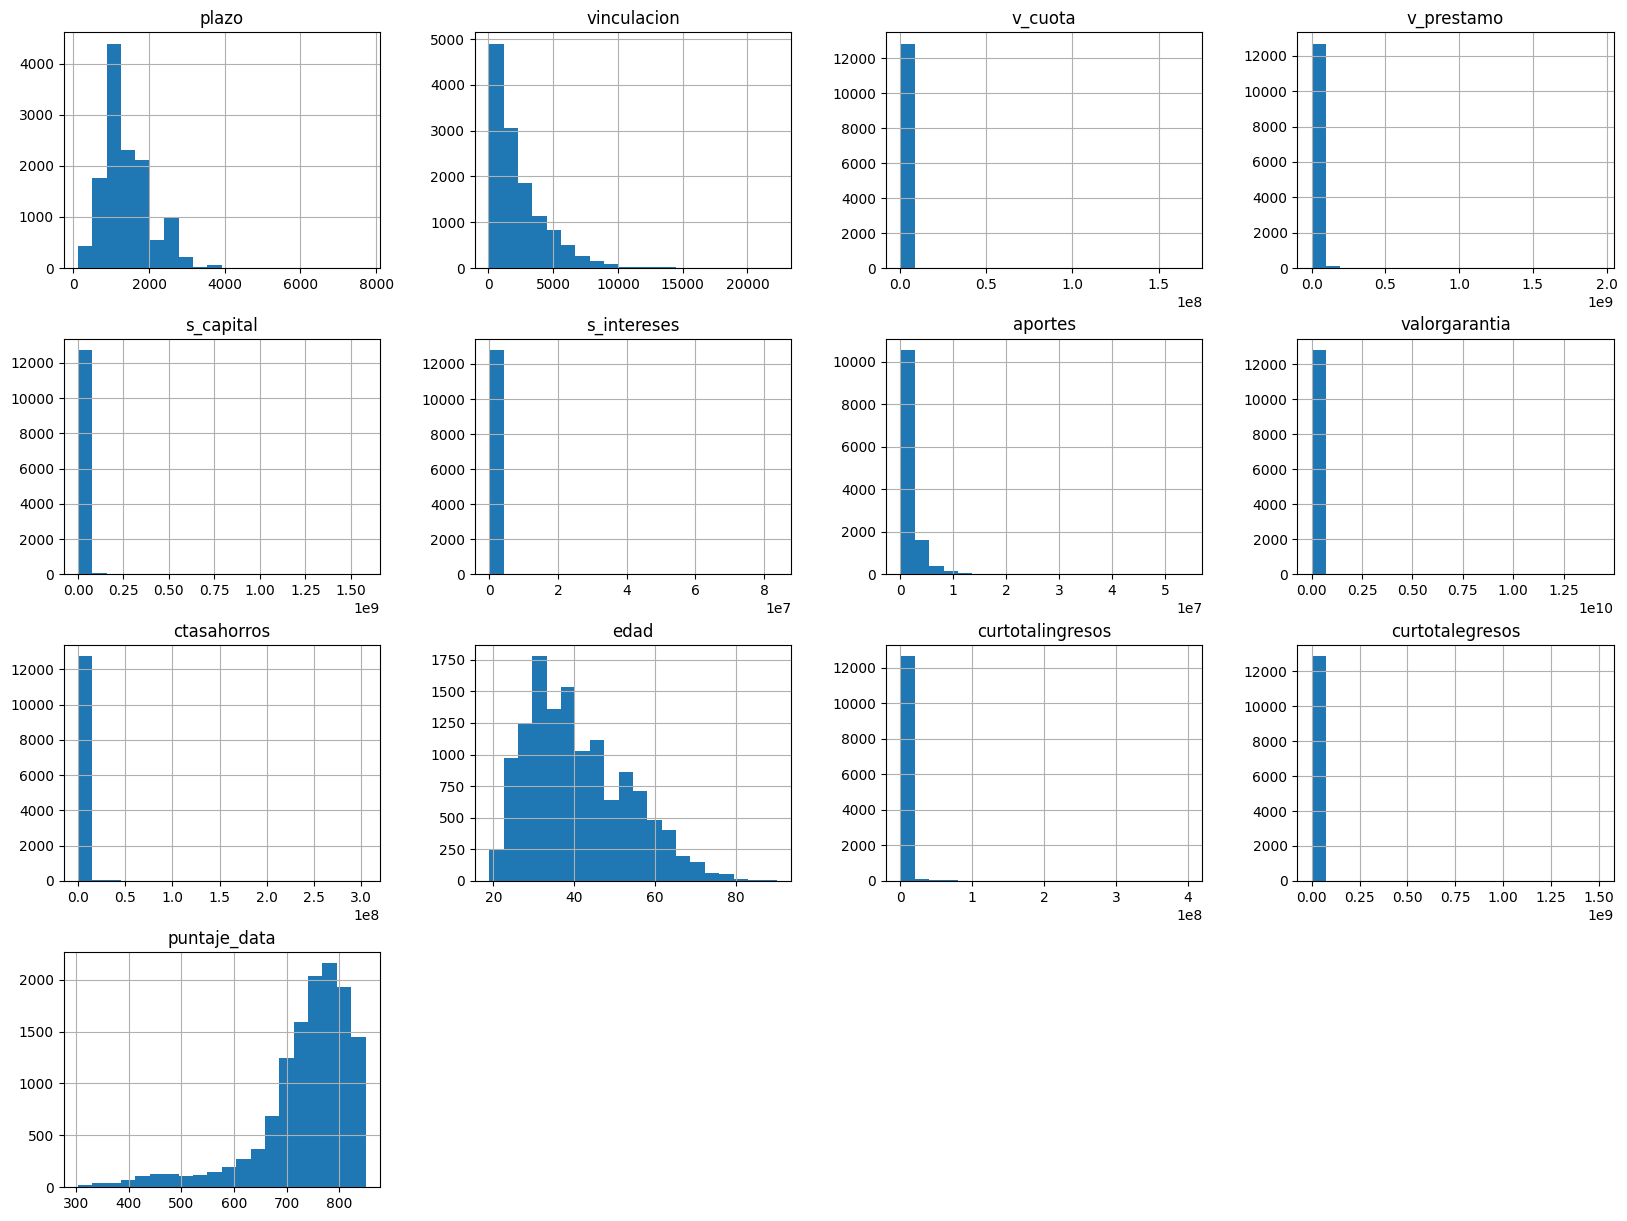

In [125]:
df.hist(bins=20, figsize=(20, 15));

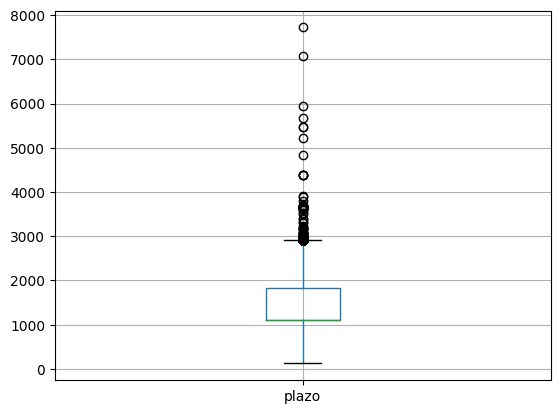

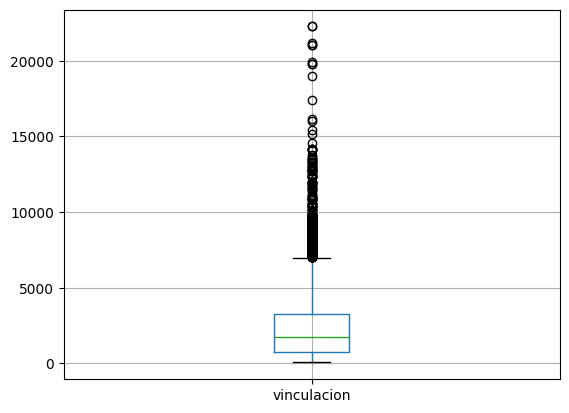

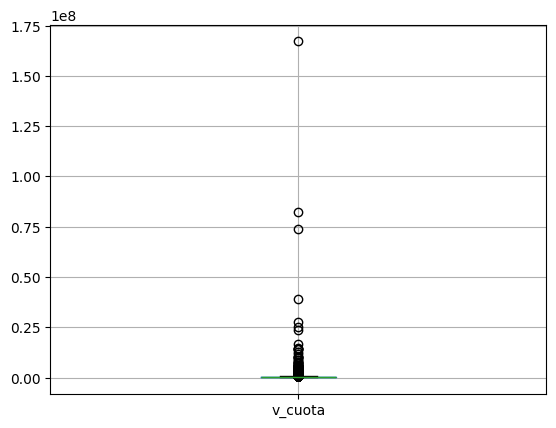

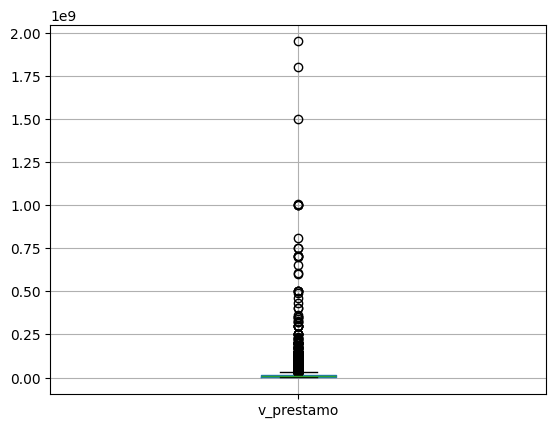

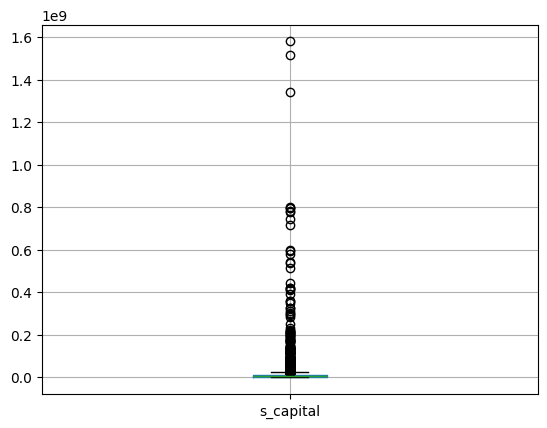

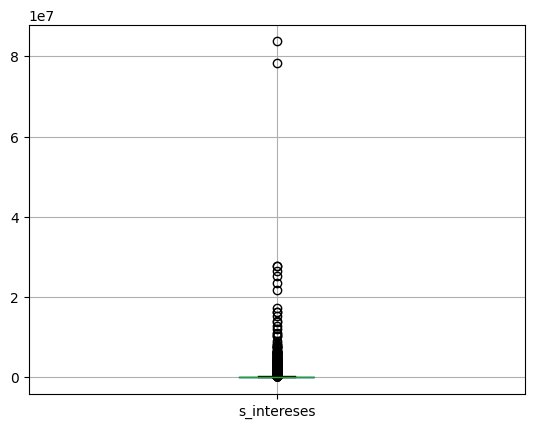

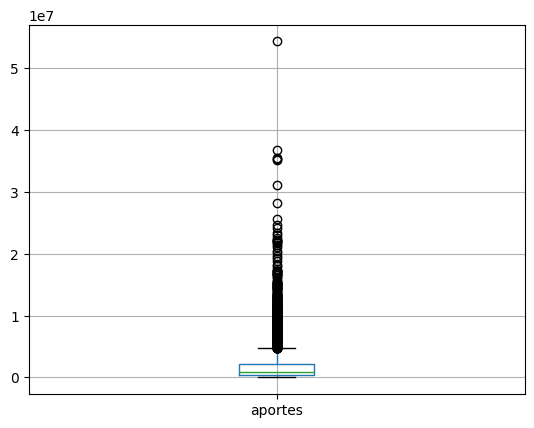

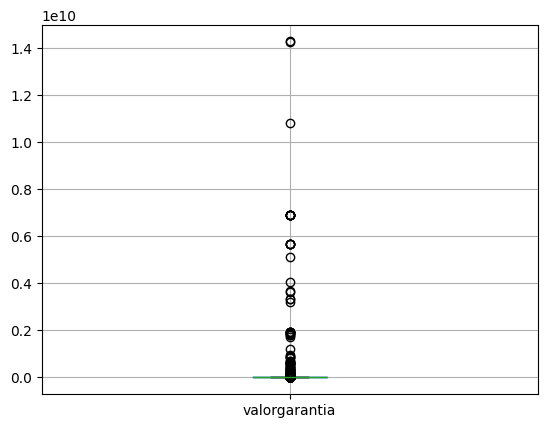

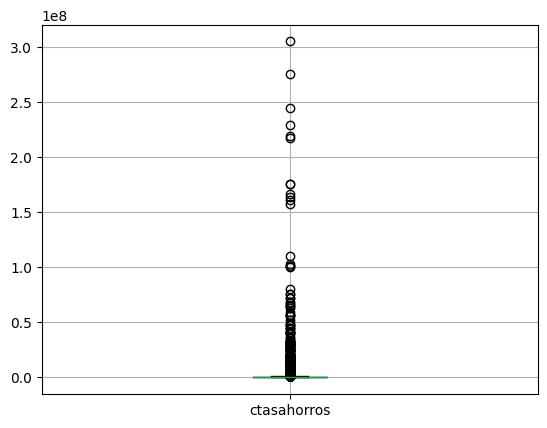

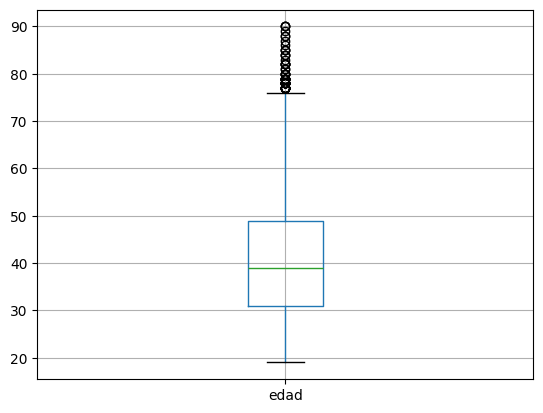

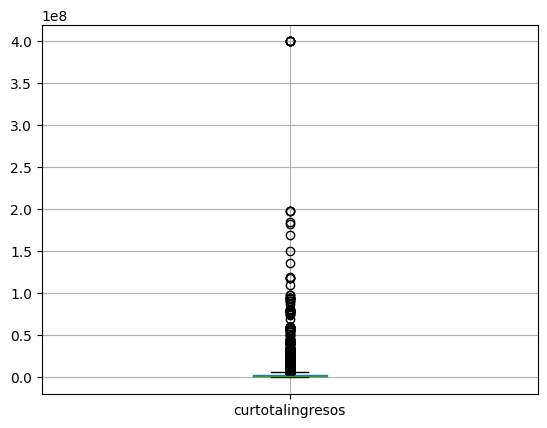

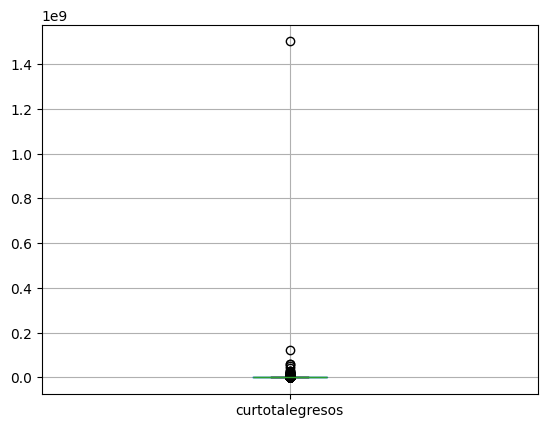

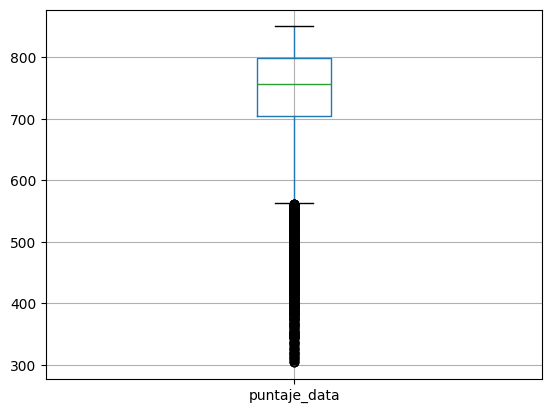

In [126]:
# Hacer boxplots de las variables numéricas para detectar outliers
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    df.boxplot(column=col)
    plt.show()

In [127]:
# Crear nuevas varaibles que sean el logaritmo de las variables numéricas para reducir
# la influencia de los outliers

import numpy as np

numeric_cols = numeric_cols.tolist()
numeric_cols.remove("edad")
numeric_cols.remove("plazo")
numeric_cols.remove("puntaje_data")

for col in numeric_cols:
    df[f"log_{col}"] = np.log1p(df[col])

df.head()

,plazo,vinculacion,v_cuota,v_prestamo,s_capital,s_intereses,aportes,garantias,valorgarantia,ctasahorros,...,log_vinculacion,log_v_cuota,log_v_prestamo,log_s_capital,log_s_intereses,log_aportes,log_valorgarantia,log_ctasahorros,log_curtotalingresos,log_curtotalegresos
n_credito,,,,,,,,,,,,,,,,,,,,,
003-002-0125852-7,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,1,7741255,33042953.0,...,9.000113,12.785071,16.523561,16.374561,11.726875,15.862075,15.862075,17.313319,15.340915,14.220976
004-002-0068475-5,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,1,4601706,3791115.0,...,7.268920,14.790225,18.425270,17.278473,12.480920,15.341938,15.341938,15.148171,15.340915,13.384729
003-002-0122592-9,1826,573,791482.0,30000000.0,23844684.0,261477,530431,1,530431,94435.0,...,6.352629,13.581664,17.216708,16.987072,12.474105,13.181447,13.181447,11.455678,15.297115,14.508658
006-002-0023879-0,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,2,320385440,54841.0,...,7.551187,14.866508,18.985995,18.550327,13.824045,14.921937,19.585035,10.912212,16.907462,14.220976
006-002-0026159-4,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,2,320385440,54841.0,...,7.551187,13.803072,17.733516,17.466721,12.667187,13.838331,19.585035,10.912212,16.907462,14.220976


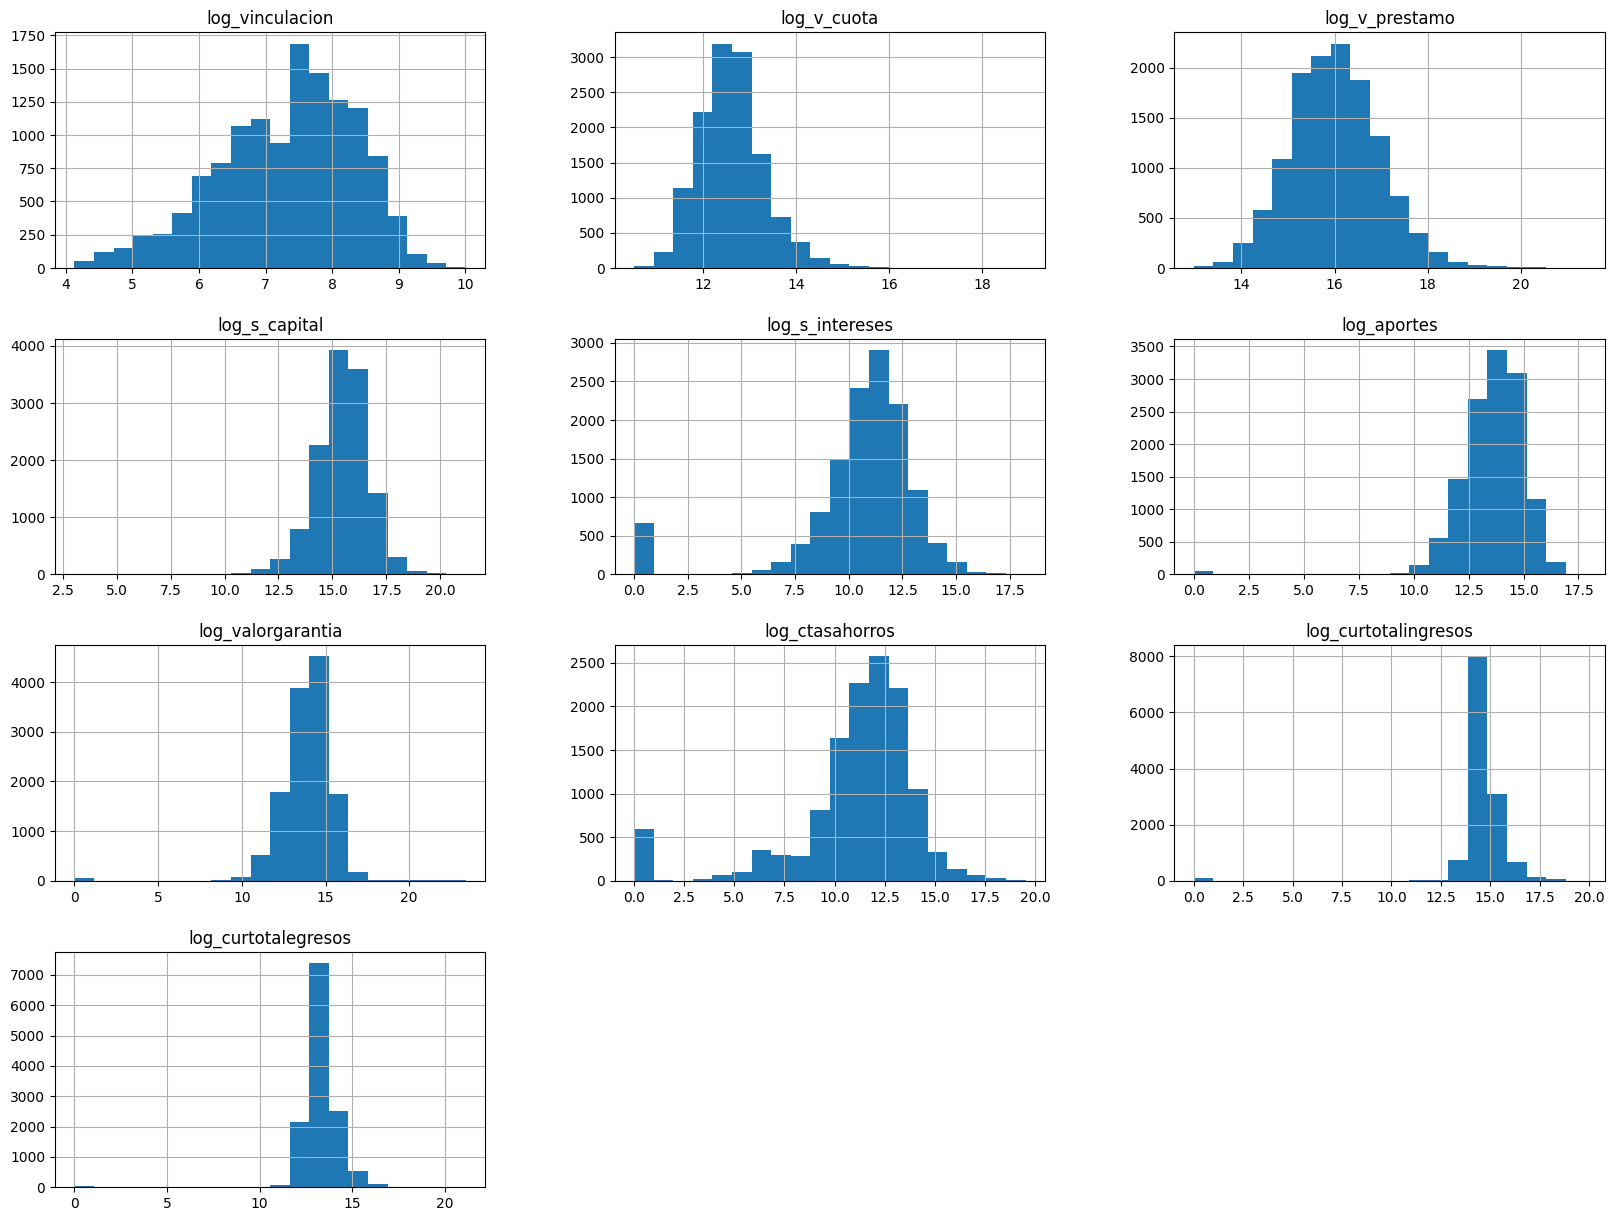

In [128]:
df_log = df[[col for col in df.columns if col.startswith("log_")]]
df_log.hist(bins=20, figsize=(20, 15));

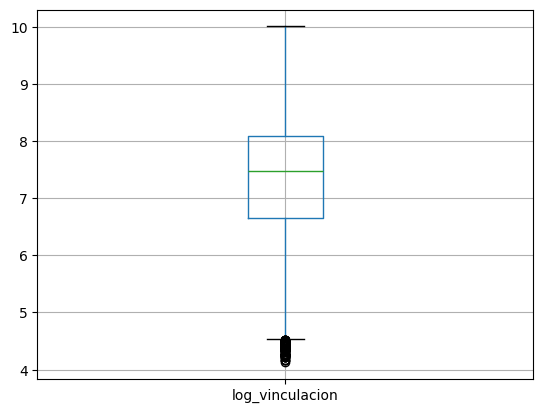

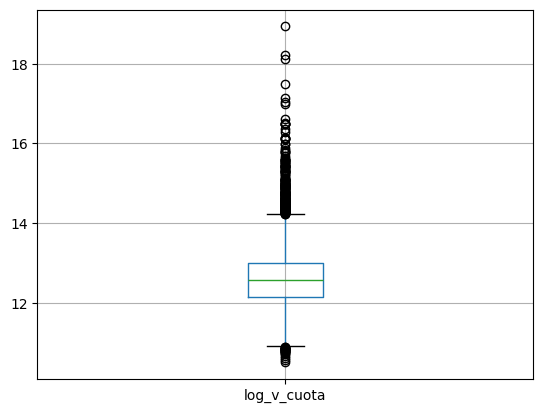

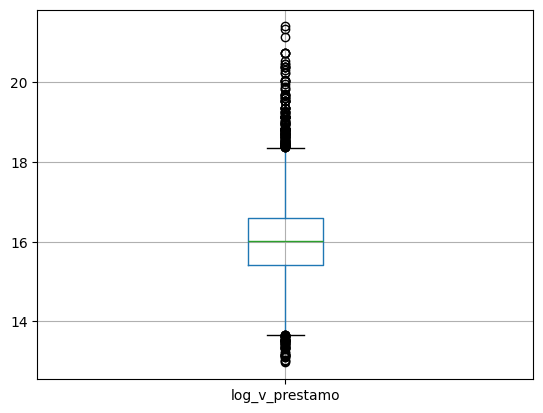

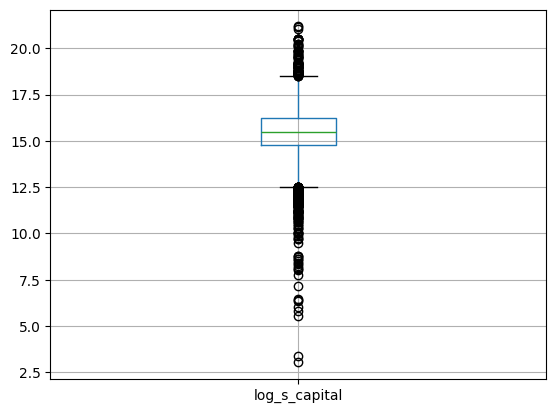

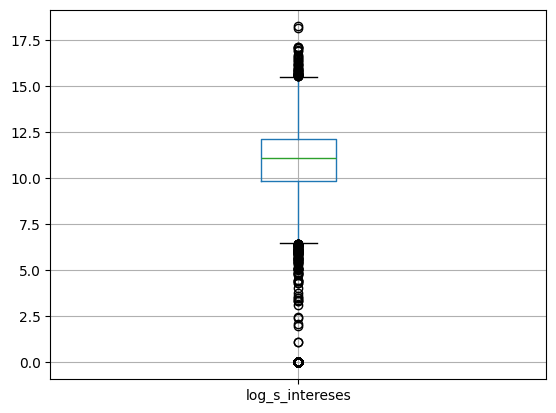

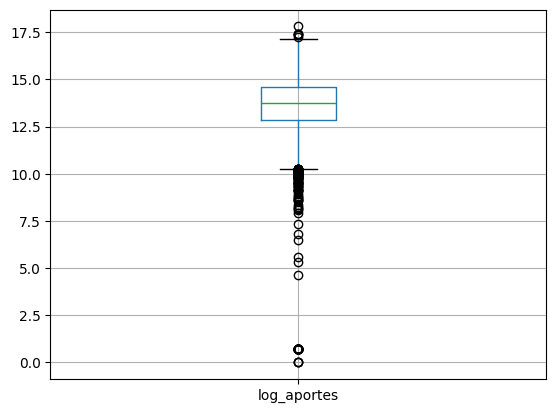

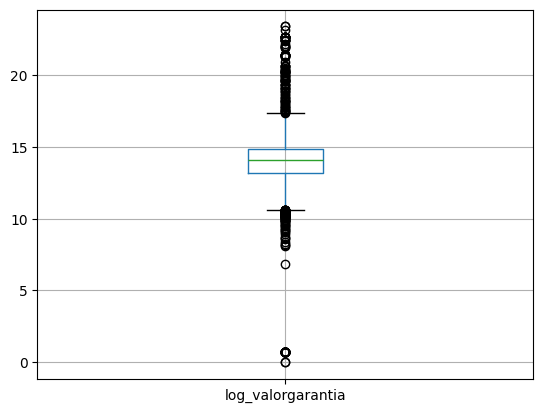

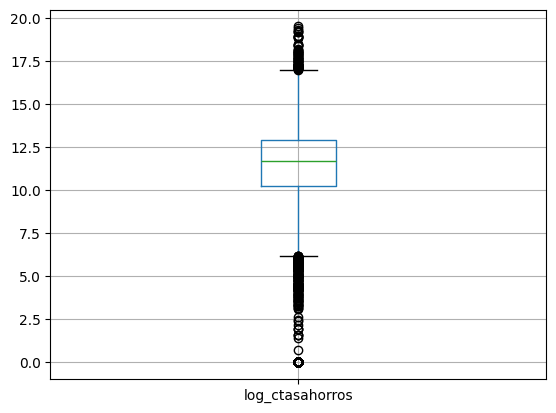

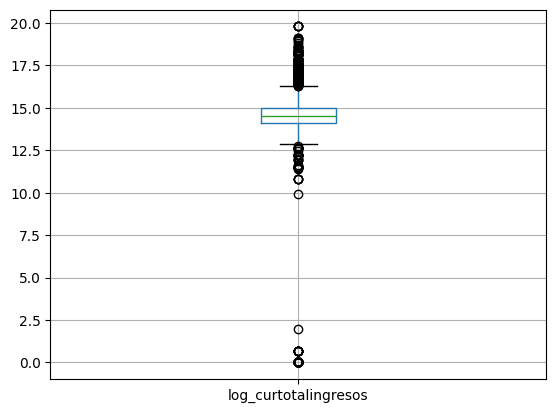

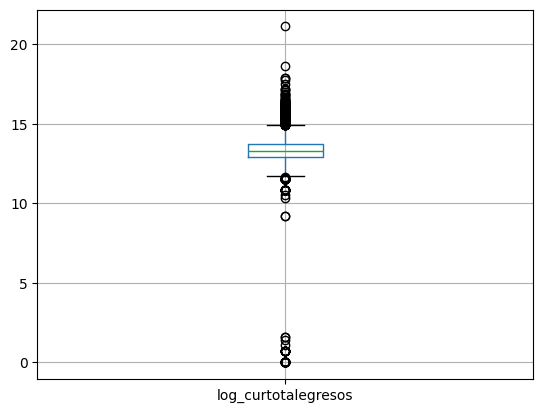

In [129]:
# Boxplots de las variables logarítmicas para verificar que se han reducido los outliers
for col in df_log.columns:
    df.boxplot(column=col)
    plt.show()

## Análisis bivariado

In [130]:
df_log.head()

,log_vinculacion,log_v_cuota,log_v_prestamo,log_s_capital,log_s_intereses,log_aportes,log_valorgarantia,log_ctasahorros,log_curtotalingresos,log_curtotalegresos
n_credito,,,,,,,,,,
003-002-0125852-7,9.000113,12.785071,16.523561,16.374561,11.726875,15.862075,15.862075,17.313319,15.340915,14.220976
004-002-0068475-5,7.268920,14.790225,18.425270,17.278473,12.480920,15.341938,15.341938,15.148171,15.340915,13.384729
003-002-0122592-9,6.352629,13.581664,17.216708,16.987072,12.474105,13.181447,13.181447,11.455678,15.297115,14.508658
006-002-0023879-0,7.551187,14.866508,18.985995,18.550327,13.824045,14.921937,19.585035,10.912212,16.907462,14.220976
006-002-0026159-4,7.551187,13.803072,17.733516,17.466721,12.667187,13.838331,19.585035,10.912212,16.907462,14.220976


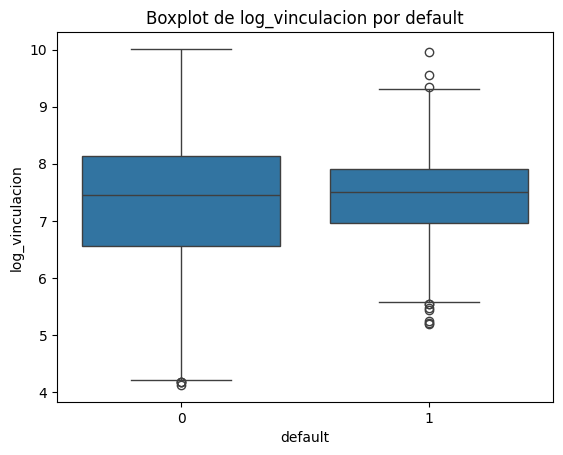

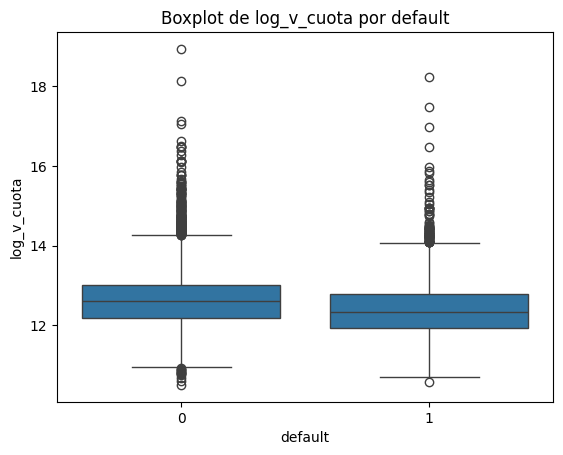

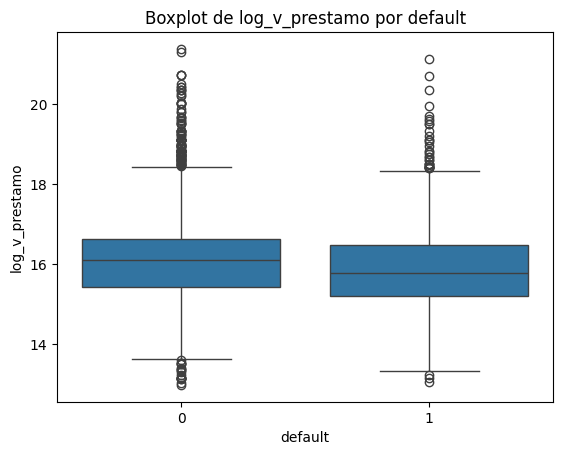

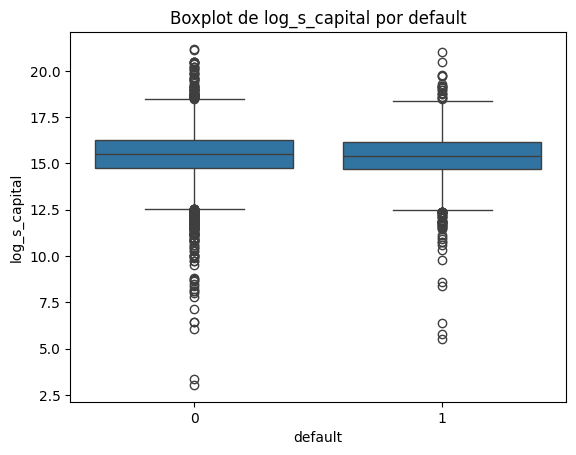

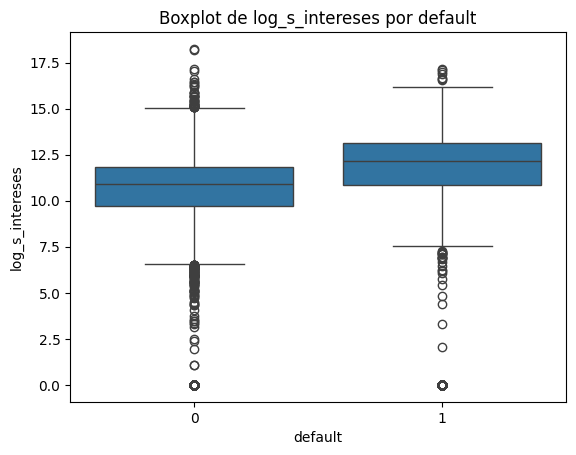

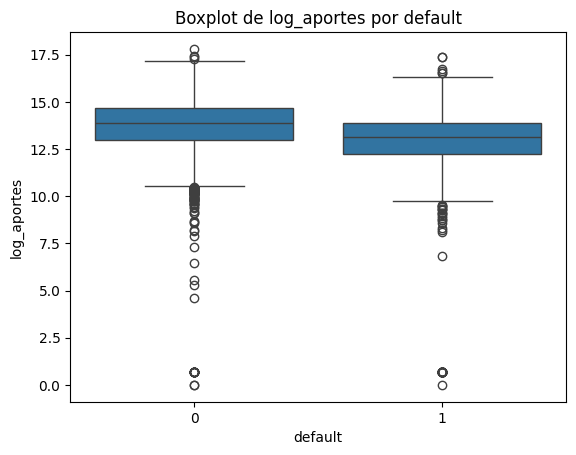

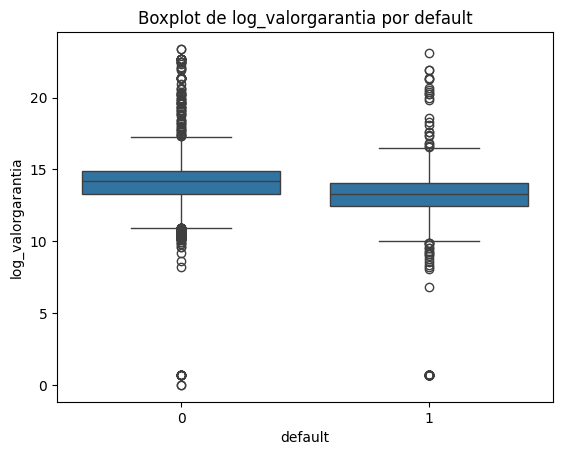

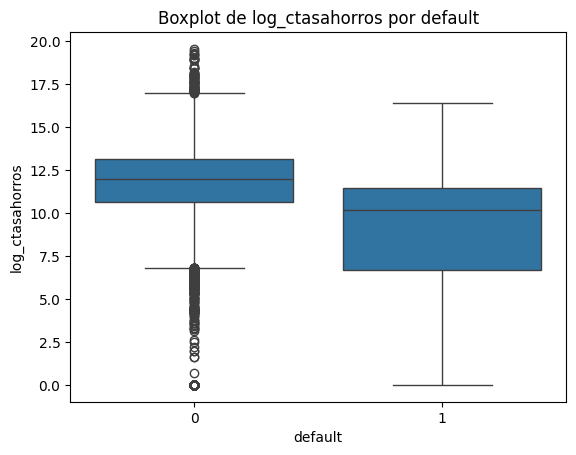

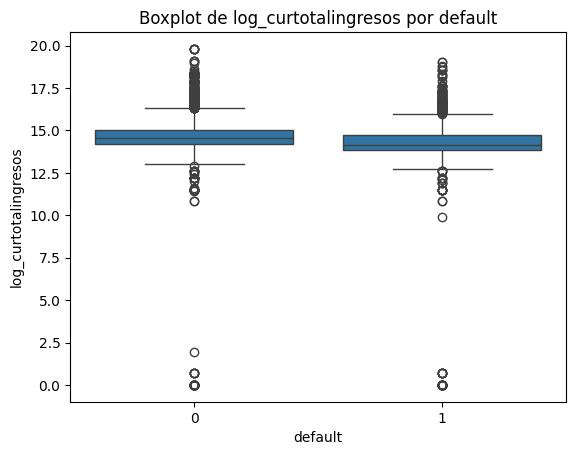

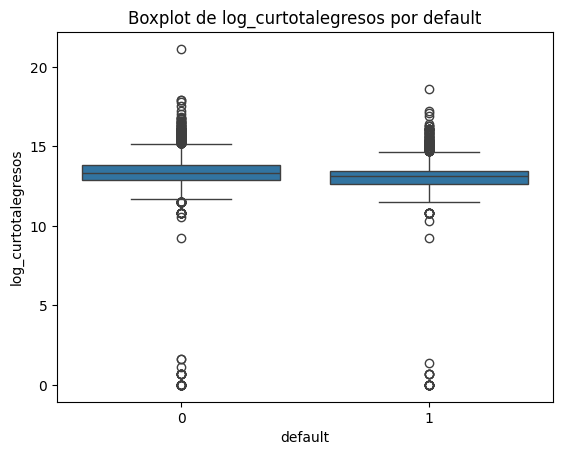

In [131]:
import seaborn as sns

df_log = pd.concat([df_log, df["default"]], axis=1)

log_vars = df_log.select_dtypes(include=["float64"]).columns
for col in log_vars:
    sns.boxplot(x="default", y=col, data=df_log)
    plt.title(f"Boxplot de {col} por default")
    plt.show()

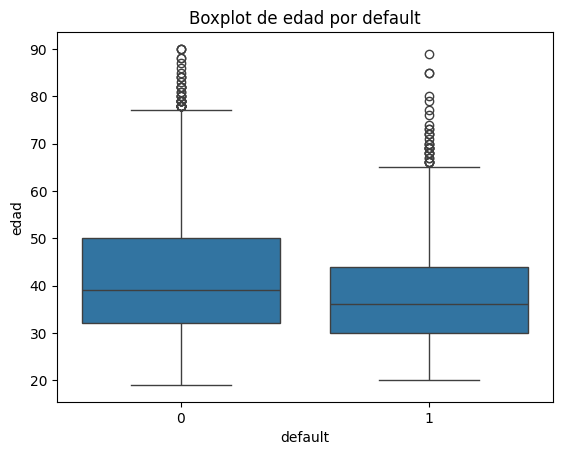

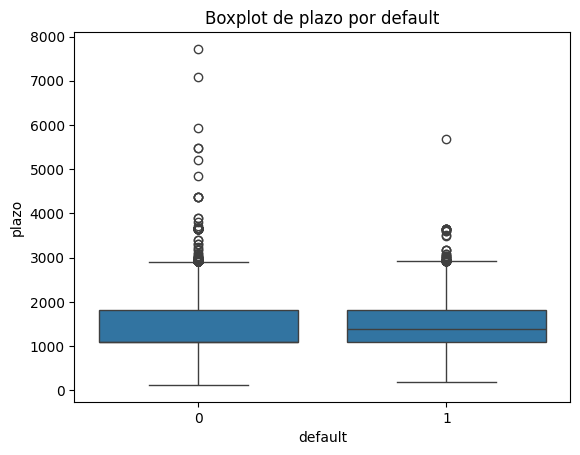

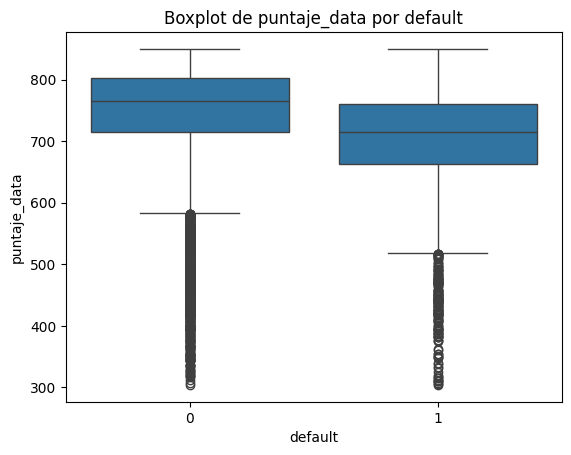

In [132]:
no_log_vars = ["edad", "plazo", "puntaje_data"]
for col in no_log_vars:
    sns.boxplot(x="default", y=col, data=df)
    plt.title(f"Boxplot de {col} por default")
    plt.show()

## Variables categóricas

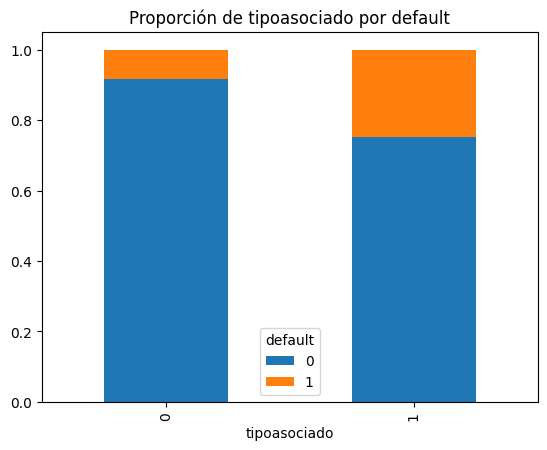

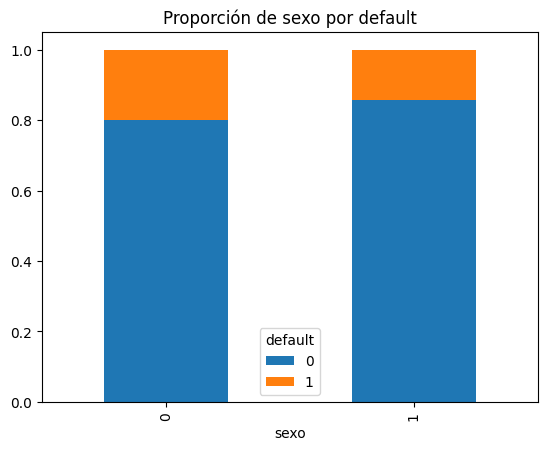

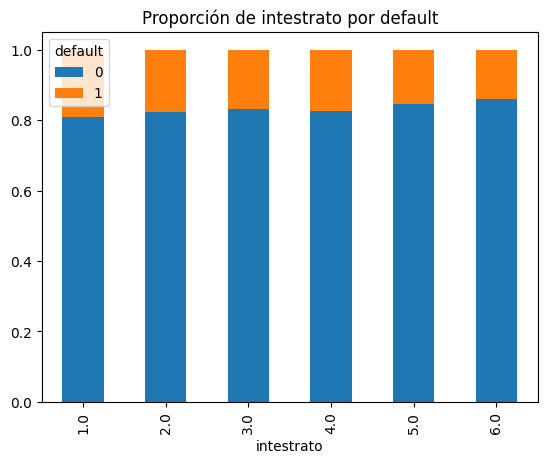

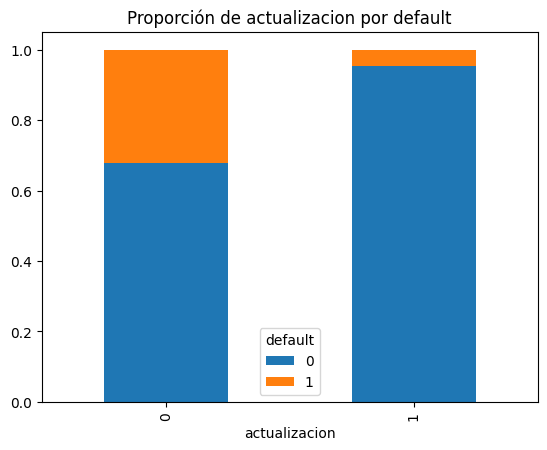

In [133]:
cat_cols = (
    df.drop(
        columns=[
            "departamento",
            "actividadeconomica",
            "estado_cliente",
            "garantias",
            "default",
        ]
    )
    .select_dtypes(include=["category"])
    .columns
)

for col in cat_cols:
    tabla = pd.crosstab(df[col], df["default"], normalize="index")
    tabla.plot.bar(stacked=True)
    plt.title(f"Proporción de {col} por default")
    plt.show()

In [134]:
# Binarizar las variables departamento, estado_cliente y actividadeconomica para
# usarlas en modelos de machine learning

from sklearn.preprocessing import OneHotEncoder

oe_encoder = OneHotEncoder(
    drop="first", sparse_output=False, dtype=int, max_categories=2
)

cat_cols_to_encode = ["departamento", "estado_cliente", "actividadeconomica"]
encoded_cols = oe_encoder.fit_transform(df[cat_cols_to_encode])
encoded_col_names = oe_encoder.get_feature_names_out(cat_cols_to_encode)
encoded_df = pd.DataFrame(encoded_cols, columns=encoded_col_names, index=df.index)
df = pd.concat([df, encoded_df], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   plazo                                  12860 non-null  int64   
 1   vinculacion                            12860 non-null  int64   
 2   v_cuota                                12860 non-null  float64 
 3   v_prestamo                             12860 non-null  float64 
 4   s_capital                              12860 non-null  float64 
 5   s_intereses                            12860 non-null  int64   
 6   aportes                                12860 non-null  int64   
 7   garantias                              12860 non-null  category
 8   valorgarantia                          12860 non-null  int64   
 9   ctasahorros                            12860 non-null  float64 
 10  edad                               

In [135]:
df["departamento_infrequent_sklearn"].value_counts()

departamento_infrequent_sklearn
0    12643
1      217
Name: count, dtype: int64

In [136]:
df["estado_cliente_infrequent_sklearn"].value_counts()

estado_cliente_infrequent_sklearn
0    12755
1      105
Name: count, dtype: int64

In [137]:
df["actividadeconomica_infrequent_sklearn"].value_counts()

actividadeconomica_infrequent_sklearn
0    11453
1     1407
Name: count, dtype: int64

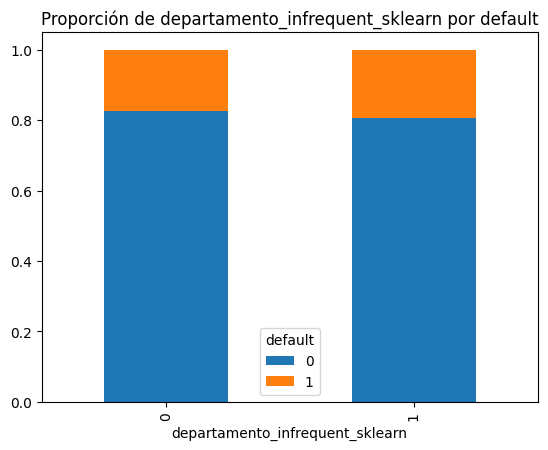

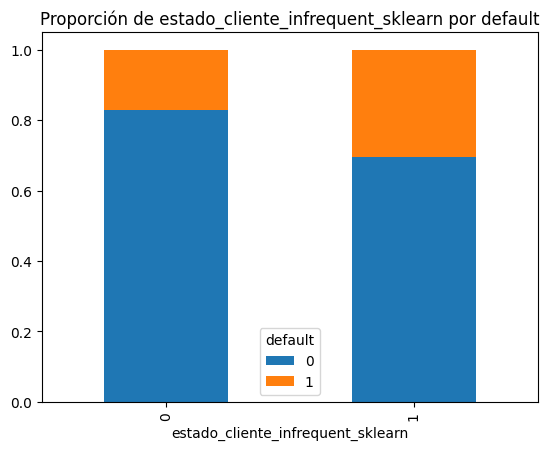

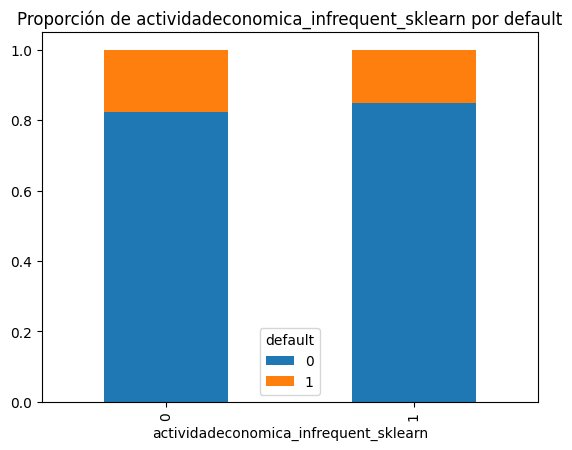

In [138]:
bin_cols = [
    "departamento_infrequent_sklearn",
    "estado_cliente_infrequent_sklearn",
    "actividadeconomica_infrequent_sklearn",
]

for col in bin_cols:
    tabla = pd.crosstab(df[col], df["default"], normalize="index")
    tabla.plot.bar(stacked=True)
    plt.title(f"Proporción de {col} por default")
    plt.show()

In [139]:
# Codificar en 3 categorías la variable garantias

from sklearn.preprocessing import OrdinalEncoder

or_encoder_garantias = OrdinalEncoder(dtype=int, max_categories=3)

df["garantias_encoded"] = or_encoder_garantias.fit_transform(df[["garantias"]])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   plazo                                  12860 non-null  int64   
 1   vinculacion                            12860 non-null  int64   
 2   v_cuota                                12860 non-null  float64 
 3   v_prestamo                             12860 non-null  float64 
 4   s_capital                              12860 non-null  float64 
 5   s_intereses                            12860 non-null  int64   
 6   aportes                                12860 non-null  int64   
 7   garantias                              12860 non-null  category
 8   valorgarantia                          12860 non-null  int64   
 9   ctasahorros                            12860 non-null  float64 
 10  edad                               

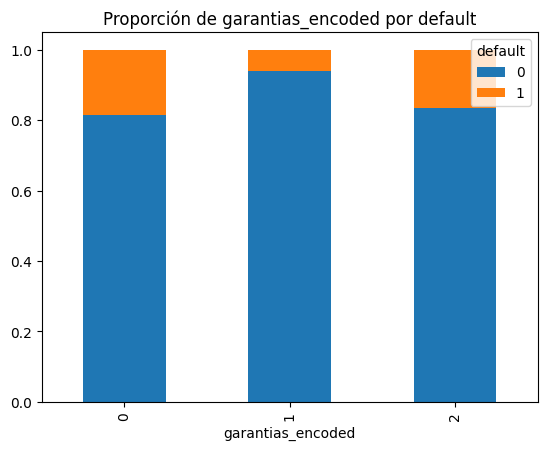

In [140]:
tabla = pd.crosstab(df["garantias_encoded"], df["default"], normalize="index")
tabla.plot.bar(stacked=True)
plt.title("Proporción de garantias_encoded por default")
plt.show()

In [141]:
df["garantias_encoded"].value_counts()

garantias_encoded
0    11583
1     1187
2       90
Name: count, dtype: int64

## Se guarda dataframe limpio

In [143]:
# Guardar el DataFrame limpio, pero eliminando las variables creadas
df_clean = df.drop(
    columns=[
        col
        for col in df.columns
        if col.startswith("log_") or col.endswith("_infrequent_sklearn")
    ],
    axis=1,
)

df_clean = df_clean.drop(columns=["garantias_encoded"], axis=1)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12860 entries, 003-002-0125852-7 to 003-002-0119478-4
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   plazo               12860 non-null  int64   
 1   vinculacion         12860 non-null  int64   
 2   v_cuota             12860 non-null  float64 
 3   v_prestamo          12860 non-null  float64 
 4   s_capital           12860 non-null  float64 
 5   s_intereses         12860 non-null  int64   
 6   aportes             12860 non-null  int64   
 7   garantias           12860 non-null  category
 8   valorgarantia       12860 non-null  int64   
 9   ctasahorros         12860 non-null  float64 
 10  edad                12860 non-null  float64 
 11  tipoasociado        12860 non-null  category
 12  actividadeconomica  12851 non-null  category
 13  estado_cliente      12860 non-null  category
 14  departamento        12859 non-null  category
 15  sexo         

In [145]:
df_clean.to_parquet(DATA_DIR / "cleaned_data_default.parquet", index=True)